In [4]:
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Input
from tensorflow.keras import models
inputs = Input(shape=(224, 224, 3))
x = Conv2D(25, (3,3), activation='relu')(inputs)
x = MaxPooling2D()(x)
x = Conv2D(64, (3,3), activation='relu', name='target_conv_layer')(x)
x = MaxPooling2D()(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)

model = models.Model(inputs, outputs)


In [10]:
from tensorflow.keras.preprocessing import image
import numpy as np
img_path = 'cat.jpg'
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0  

In [11]:
import tensorflow as tf
grad_model = tf.keras.models.Model(
    [model.input],
    [model.get_layer('target_conv_layer').output, model.output]
)

In [12]:
conv_output,predictions = grad_model(img_array)
conv_output = conv_output[0].numpy()

C:\Users\karth\AppData\Roaming\Python\Python312\site-packages\keras\src\models\functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_8']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


In [19]:
heatmap = np.mean(conv_output,axis=-1)
heatmap = np.maximum(heatmap,0)
heatmap = heatmap / np.max(heatmap)

In [20]:
import cv2
heatmap = cv2.resize(heatmap,(img.size[0],img.size[1]))

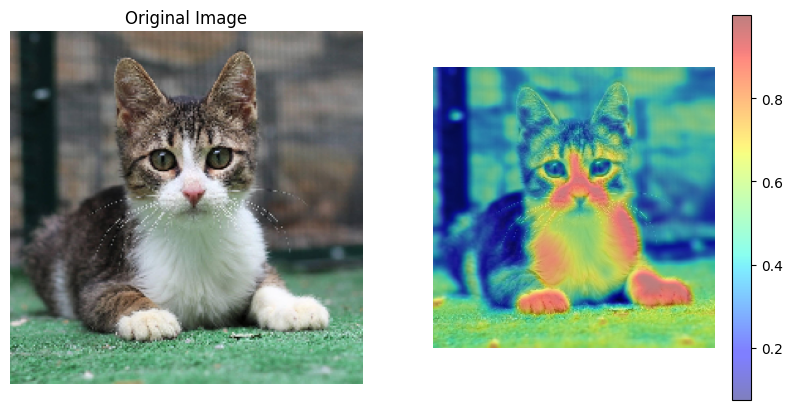

In [21]:
import matplotlib.pyplot as plt
# Create two subplots: one for the original image, one for the Grad-CAM overlay
plt.figure(figsize=(10, 5))

# Plot the original image
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')  # Turn off axis

# Plot the Grad-CAM heatmap overlay
plt.subplot(1, 2, 2)
plt.imshow(img)
plt.imshow(heatmap, cmap='jet', alpha=0.5)  # Overlay the heatmap with transparency
plt.colorbar()
plt.axis('off')  # Turn off axis

# Display the images
plt.show()